<a href="https://colab.research.google.com/github/WVF-1/Movie-Performance-Analytics/blob/main/Newsletter_Visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Movie Performance Analytics — Notebook 3
## Newsletter Visualisations & Story

**Series:** May Newsletter — Movie Intelligence  
**Prerequisite:** Run Notebooks 1 & 2 first

This notebook produces the **publication-ready charts** for the newsletter.  
Every figure is saved as a high-resolution PNG, ready to drop into your write-up.

### Story arc

> *"Hollywood looks glamorous from the outside — but behind every release is a financial bet.  
> Which genres pay off? Does a blockbuster budget guarantee a blockbuster return?  
> And when exactly should you open your film?"*

### Figures produced
| Figure | File | Story beat |
|--------|------|------------|
| 1 | `fig1_genre_roi_waffle.png` | Genre ROI ranking — the winners |
| 2 | `fig2_budget_scatter.png`   | The budget-revenue relationship |
| 3 | `fig3_budget_tier_violin.png`| ROI distribution by budget tier |
| 4 | `fig4_seasonal_heatmap.png` | Monthly × decade release calendar |
| 5 | `fig5_roi_profitpct.png`    | Genre ROI vs % profitable (scatter) |
| 6 | `fig6_summary_dashboard.png`| 2×2 summary dashboard |


## 0 · Setup

In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

df          = pd.read_parquet("movies_clean.parquet")
df_ranked   = df[df["budget"] > 5e6].copy()

TIER_ORDER  = ["Micro (<$1M)", "Low ($1M–$15M)", "Mid ($15M–$60M)", "Blockbuster (>$60M)"]
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

genre_stats = (
    df.groupby("primary_genre")
    .agg(film_count=("title","count"),
         median_ROI =("ROI","median"),
         pct_profit =("ROI", lambda x: (x>0).mean()*100))
    .query("film_count >= 30")
    .sort_values("median_ROI", ascending=False)
    .reset_index()
)

print(f"✔ Loaded {len(df):,} films | {len(genre_stats)} qualifying genres")


✔ Loaded 5,128 films | 17 qualifying genres


## Figure 1 · Genre ROI Ranking

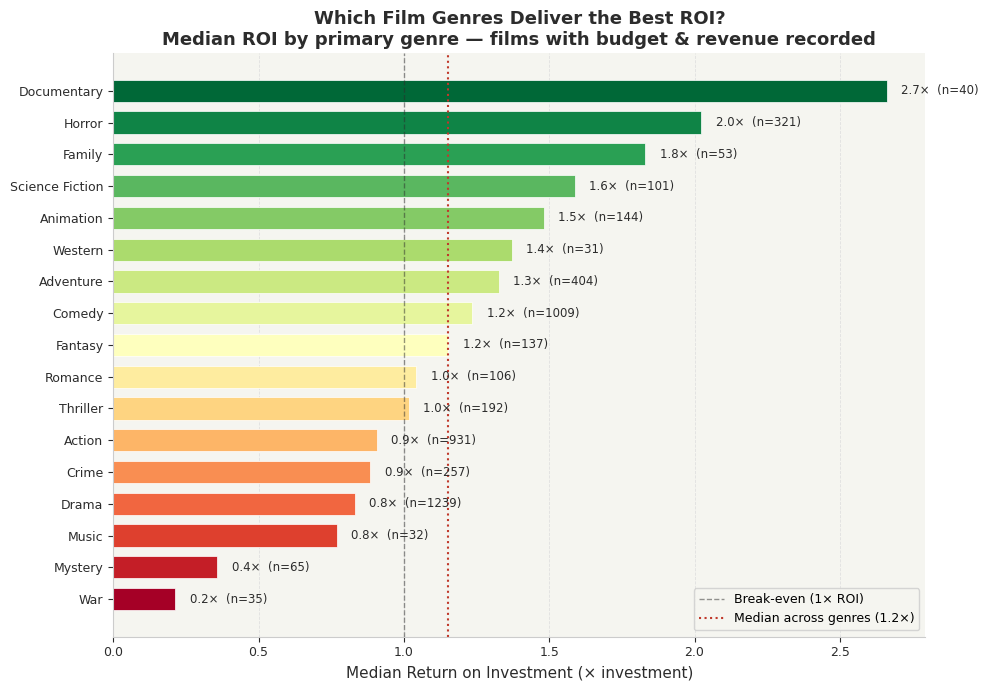

Saved: fig1_genre_roi.png


In [ ]:
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(10, 7))

g = genre_stats.sort_values("median_ROI")

# Color gradient from CRIMSON → GOLD based on rank
n = len(g)
palette = [plt.cm.RdYlGn(i / (n-1)) for i in range(n)]

bars = ax.barh(g["primary_genre"], g["median_ROI"],
               color=palette, edgecolor="white", linewidth=0.5, height=0.7)

ax.axvline(1.0, color=DARK_TEXT, linewidth=1, linestyle="--", alpha=0.5,
           label="Break-even (1× ROI)")
ax.axvline(g["median_ROI"].median(), color=CRIMSON, linewidth=1.5, linestyle=":",
           label=f"Median across genres ({g['median_ROI'].median():.1f}×)")

for bar, val, n_ in zip(bars, g["median_ROI"], g["film_count"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}×  (n={n_})",
            va="center", fontsize=8.5, color=DARK_TEXT)

ax.set_xlabel("Median Return on Investment (× investment)", fontsize=11)
ax.set_title("Which Film Genres Deliver the Best ROI?\nMedian ROI by primary genre — films with budget & revenue recorded",
             fontsize=13, fontweight="bold", color=DARK_TEXT)
ax.legend(fontsize=9, framealpha=0.8)
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig("fig1_genre_roi.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig1_genre_roi.png")

## Figure 2 · Budget vs Revenue Scatter

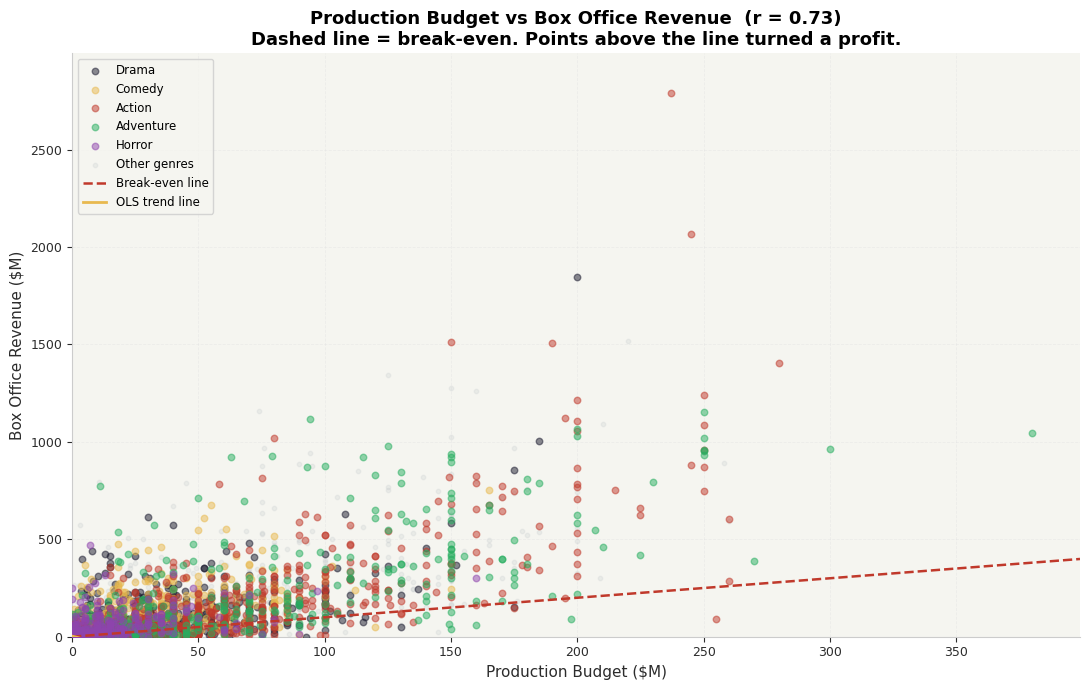

Saved: fig2_budget_scatter.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

from scipy.stats import pearsonr

fig, ax = plt.subplots(figsize=(11, 7))

# Jitter-free scatter — colour by genre group
top5 = df["primary_genre"].value_counts().head(5).index.tolist()
pal5 = [MIDNIGHT, GOLD, CRIMSON, "#27ae60", "#8e44ad"]
GMAP = dict(zip(top5, pal5))

for genre, color in GMAP.items():
    s = df[df["primary_genre"] == genre]
    ax.scatter(s["budget"]/1e6, s["revenue"]/1e6,
               color=color, alpha=0.5, s=22, label=genre, zorder=3)

others = df[~df["primary_genre"].isin(top5)]
ax.scatter(others["budget"]/1e6, others["revenue"]/1e6,
           color=SILVER, alpha=0.2, s=10, label="Other genres", zorder=2)

# Break-even line
xlim = df["budget"].max() / 1e6 * 1.05
ax.plot([0, xlim], [0, xlim], color=CRIMSON, linestyle="--",
        linewidth=1.8, label="Break-even line", zorder=5)

# OLS regression line
from numpy.polynomial.polynomial import polyfit
mask = df["budget"].notna() & df["revenue"].notna()
b, m = polyfit(df.loc[mask,"budget"]/1e6, df.loc[mask,"revenue"]/1e6, deg=1)
x_range = np.linspace(0, xlim, 200)
ax.plot(x_range, m + b*x_range, color=GOLD, linewidth=2,
        linestyle="-", label="OLS trend line", zorder=6)

r, _ = pearsonr(df.loc[mask,"budget"]/1e6, df.loc[mask,"revenue"]/1e6)
ax.set_xlabel("Production Budget ($M)", fontsize=11)
ax.set_ylabel("Box Office Revenue ($M)", fontsize=11)
ax.set_title(f"""Production Budget vs Box Office Revenue  (r = {r:.2f})
Dashed line = break-even. Points above the line turned a profit.""",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8.5, framealpha=0.8, loc="upper left")
style_spines(ax)
ax.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlim(0, xlim)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("fig2_budget_scatter.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig2_budget_scatter.png")


## Figure 3 · ROI Distribution by Budget Tier (Violin)

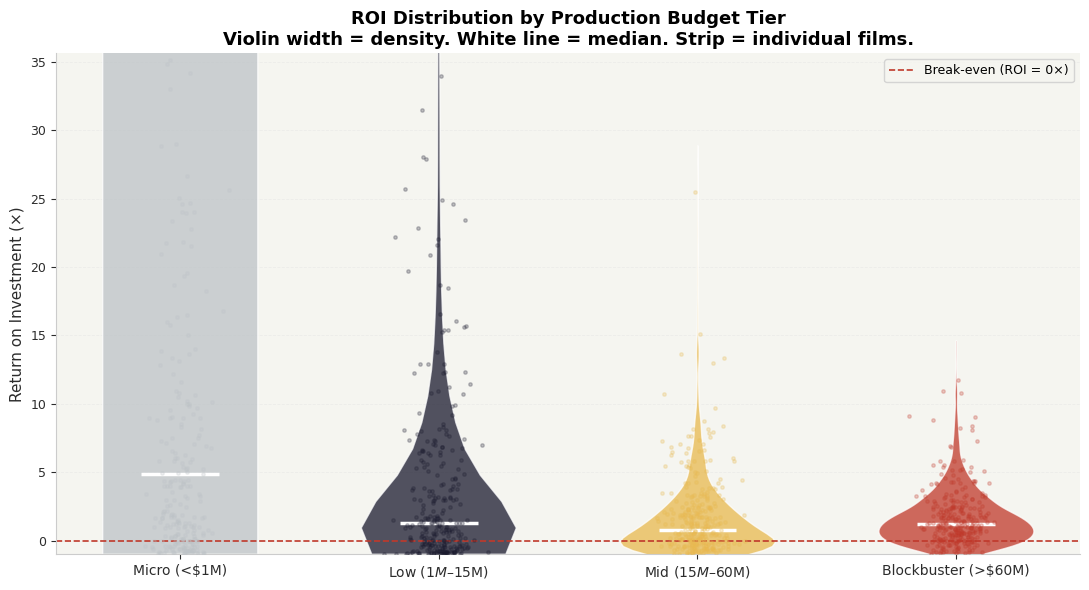

Saved: fig3_budget_tier_violin.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(11, 6))

tier_data   = [df[df["budget_tier"] == t]["ROI"].dropna() for t in TIER_ORDER]
tier_colors = [SILVER, MIDNIGHT, GOLD, CRIMSON]

parts = ax.violinplot(tier_data, showmedians=True, showextrema=False,
                      positions=range(len(TIER_ORDER)), widths=0.6)

for pc, color in zip(parts["bodies"], tier_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)
    pc.set_edgecolor("white")

parts["cmedians"].set_color("white")
parts["cmedians"].set_linewidth(2.5)

# Overlay jittered strip
for i, (data, color) in enumerate(zip(tier_data, tier_colors)):
    sample = data.sample(min(300, len(data)), random_state=42)
    jitter = np.random.normal(i, 0.06, size=len(sample))
    ax.scatter(jitter, sample, alpha=0.25, s=6, color=color, zorder=3)

ax.set_xticks(range(len(TIER_ORDER)))
ax.set_xticklabels(TIER_ORDER, fontsize=10)
ax.set_ylabel("Return on Investment (×)", fontsize=11)
ax.set_title("ROI Distribution by Production Budget Tier\n"
             "Violin width = density. White line = median. Strip = individual films.",
             fontsize=13, fontweight="bold")
ax.axhline(0, color=CRIMSON, linestyle="--", linewidth=1.2, label="Break-even (ROI = 0×)")
ax.legend(fontsize=9)
ax.set_ylim(-1, df["ROI_capped"].quantile(0.98))
style_spines(ax)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig3_budget_tier_violin.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig3_budget_tier_violin.png")


## Figure 4 · Seasonal Heatmap — Releases by Month & Decade

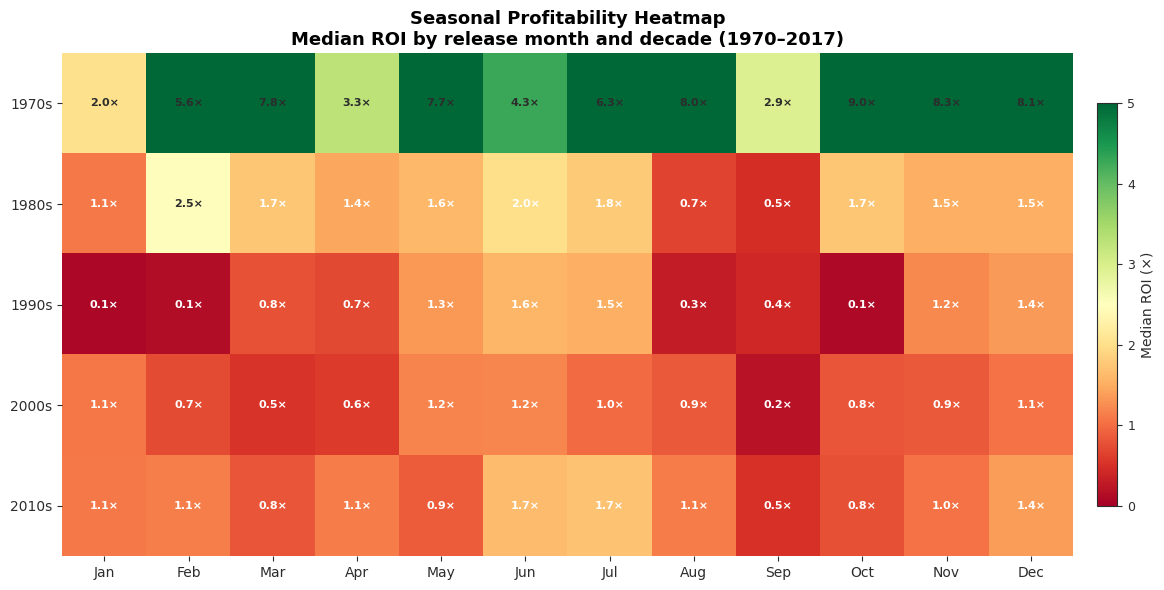

Saved: fig4_seasonal_heatmap.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import matplotlib.colors as mcolors

pivot = (
    df[df["release_year"].between(1970, 2017)]
    .groupby(["decade", "release_month"])
    .agg(median_ROI=("ROI","median"), film_count=("title","count"))
    .reset_index()
    .pivot(index="decade", columns="release_month", values="median_ROI")
)
pivot.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(13, 6))

im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=5)

ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_NAMES, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{int(d)}s" for d in pivot.index], fontsize=10)

# Annotate cells
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}×", ha="center", va="center",
                    fontsize=8, color="white" if val < 2 else DARK_TEXT, fontweight="bold")

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Median ROI (×)", fontsize=10)

ax.set_title("""Seasonal Profitability Heatmap
Median ROI by release month and decade (1970–2017)""",
             fontsize=13, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("fig4_seasonal_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig4_seasonal_heatmap.png")

## Figure 5 · Genre: ROI vs % of Films That Turn a Profit

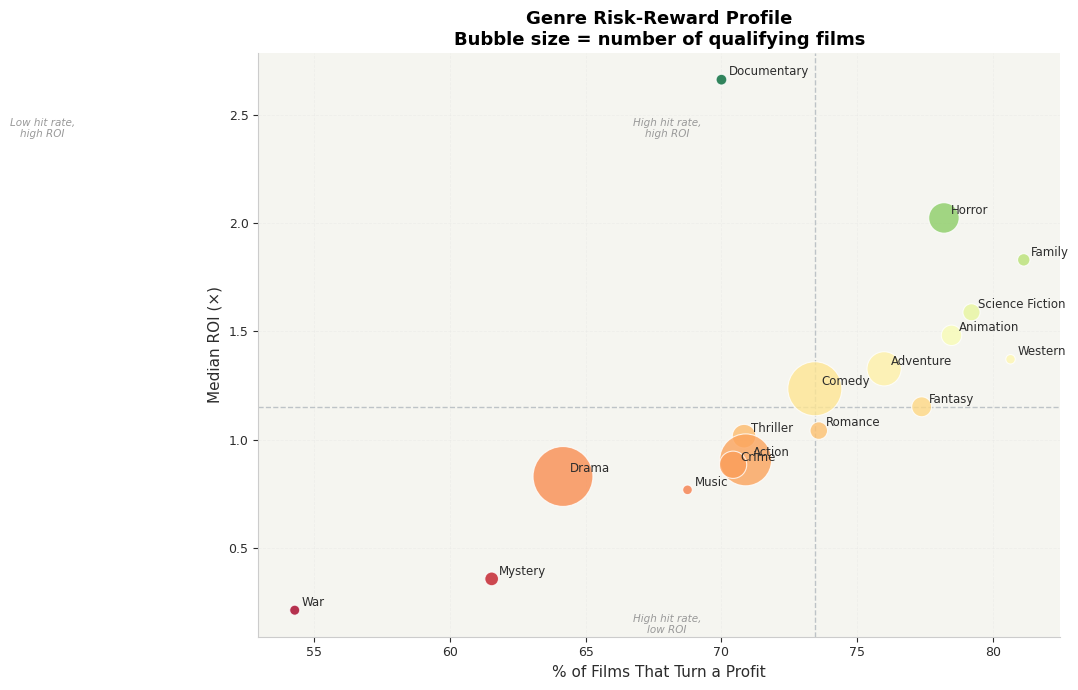

Saved: fig5_roi_profitpct.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(11, 7))

x = genre_stats["pct_profit"]
y = genre_stats["median_ROI"]
s = genre_stats["film_count"]

scatter = ax.scatter(x, y, s=s*1.5, alpha=0.8,
                     c=y, cmap="RdYlGn", edgecolors="white", linewidths=0.8, zorder=3)

# Genre labels with smart offset
for _, row in genre_stats.iterrows():
    ax.annotate(row["primary_genre"],
                xy=(row["pct_profit"], row["median_ROI"]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=8.5, color=DARK_TEXT)

# Quadrant lines
ax.axhline(genre_stats["median_ROI"].median(), color=SILVER, linestyle="--", linewidth=1)
ax.axvline(genre_stats["pct_profit"].median(),  color=SILVER, linestyle="--", linewidth=1)

ax.set_xlabel("% of Films That Turn a Profit", fontsize=11)
ax.set_ylabel("Median ROI (×)", fontsize=11)
ax.set_title("""Genre Risk-Reward Profile
Bubble size = number of qualifying films""",
             fontsize=13, fontweight="bold")

# Add quadrant labels
for txt, x_, y_ in [
    ("High hit rate,\nhigh ROI", 68, y.max()*0.9),
    ("Low hit rate,\nhigh ROI", 45, y.max()*0.9),
    ("High hit rate,\nlow ROI", 68, y.min()*0.5),
]:
    ax.text(x_, y_, txt, fontsize=7.5, color="#999999", ha="center", style="italic")

style_spines(ax)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig5_roi_profitpct.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig5_roi_profitpct.png")

## Figure 6 · 2×2 Summary Dashboard

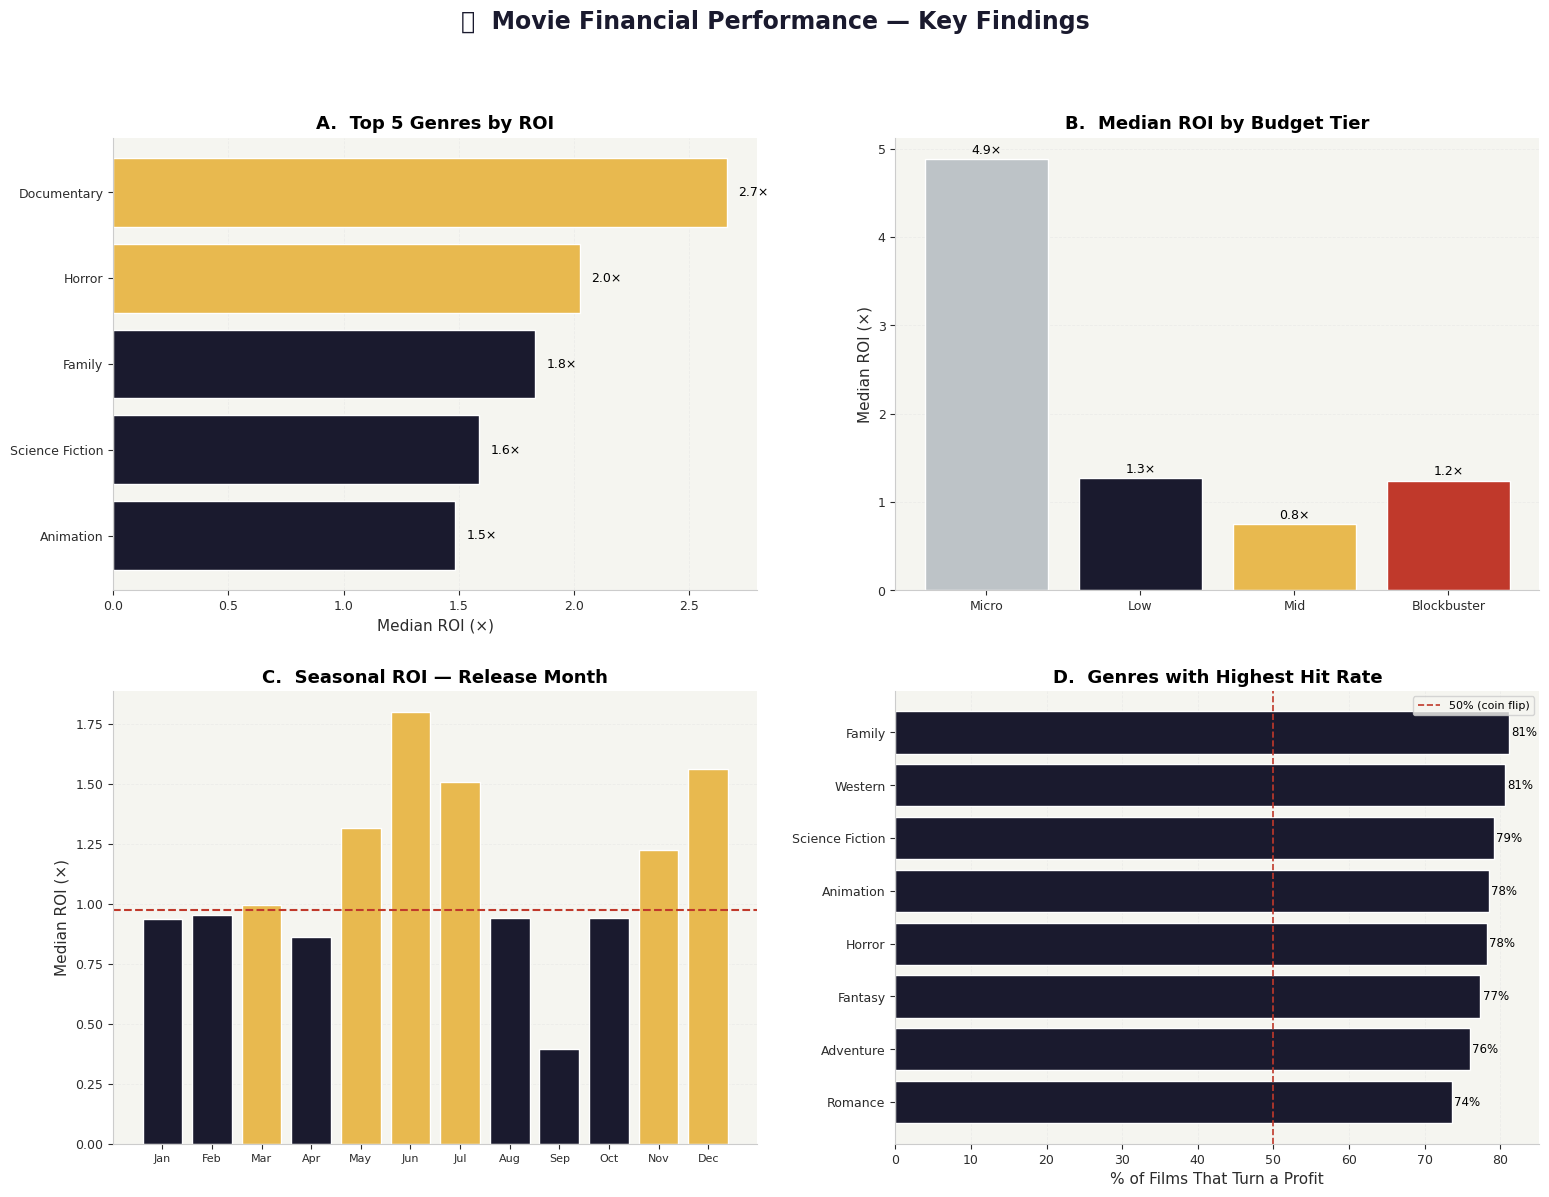

Saved: fig6_summary_dashboard.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"   # deep navy — primary bars / lines
GOLD      = "#e8b94f"   # Oscar gold — highlights / secondary
CRIMSON   = "#c0392b"   # cinema red — warning / contrast
SILVER    = "#bdc3c7"   # light silver — neutral fills
CREAM     = "#f5f5f0"   # off-white background
DARK_TEXT = "#2c2c2c"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def add_bar_labels(ax, fmt="{:.1f}", fontsize=8, color=DARK_TEXT, padding=2):
    """Annotate a bar chart with value labels."""
    for p in ax.patches:
        h = p.get_height()
        if abs(h) > 0:
            ax.annotate(fmt.format(h),
                        xy=(p.get_x() + p.get_width() / 2, h),
                        xytext=(0, padding), textcoords="offset points",
                        ha="center", va="bottom", fontsize=fontsize, color=color)

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig = plt.figure(figsize=(16, 12))
fig.suptitle("🎬  Movie Financial Performance — Key Findings",
             fontsize=17, fontweight="bold", color=MIDNIGHT, y=1.01)

# ── Panel A: Top 5 genres by ROI ────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
top5g = genre_stats.head(5).sort_values("median_ROI")
colors_a = [MIDNIGHT, MIDNIGHT, MIDNIGHT, GOLD, GOLD]
ax1.barh(top5g["primary_genre"], top5g["median_ROI"],
         color=colors_a, edgecolor="white")
ax1.set_xlabel("Median ROI (×)")
ax1.set_title("A.  Top 5 Genres by ROI")
style_spines(ax1, keep=("bottom","left"))
ax1.xaxis.grid(True, alpha=0.4)
ax1.set_axisbelow(True)
for p, val in zip(ax1.patches, top5g["median_ROI"]):
    ax1.text(p.get_width()+0.05, p.get_y()+p.get_height()/2,
             f"{val:.1f}×", va="center", fontsize=9)

# ── Panel B: Budget tier median ROI ─────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
tier_roi = (df.groupby("budget_tier")["ROI"]
              .median().reindex(TIER_ORDER).dropna())
colors_b = [SILVER, MIDNIGHT, GOLD, CRIMSON]
ax2.bar(range(len(tier_roi)), tier_roi.values,
        color=colors_b, edgecolor="white")
ax2.set_xticks(range(len(tier_roi)))
ax2.set_xticklabels(["Micro","Low","Mid","Blockbuster"], fontsize=9)
ax2.set_ylabel("Median ROI (×)")
ax2.set_title("B.  Median ROI by Budget Tier")
style_spines(ax2)
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)
for i, (pos, val) in enumerate(zip(range(len(tier_roi)), tier_roi.values)):
    ax2.text(pos, val + 0.03, f"{val:.1f}×", ha="center", va="bottom", fontsize=9)

# ── Panel C: Monthly median ROI ──────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
monthly = (df.groupby("release_month")["ROI"].median()
             .rename_axis("month").reset_index())
monthly["month_name"] = MONTH_NAMES
colors_c = [GOLD if r > monthly["ROI"].median() else MIDNIGHT for r in monthly["ROI"]]
ax3.bar(monthly["month_name"], monthly["ROI"], color=colors_c, edgecolor="white")
ax3.axhline(monthly["ROI"].median(), color=CRIMSON, linestyle="--", linewidth=1.5)
ax3.set_ylabel("Median ROI (×)")
ax3.set_title("C.  Seasonal ROI — Release Month")
ax3.tick_params(axis="x", labelsize=8)
style_spines(ax3)
ax3.yaxis.grid(True, alpha=0.4)
ax3.set_axisbelow(True)

# ── Panel D: % profitable by genre (top 8) ───────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
top8 = genre_stats.nlargest(8, "pct_profit").sort_values("pct_profit")
ax4.barh(top8["primary_genre"], top8["pct_profit"],
         color=MIDNIGHT, edgecolor="white")
ax4.axvline(50, color=CRIMSON, linestyle="--", linewidth=1.2, label="50% (coin flip)")
ax4.set_xlabel("% of Films That Turn a Profit")
ax4.set_title("D.  Genres with Highest Hit Rate")
ax4.legend(fontsize=8)
style_spines(ax4, keep=("bottom","left"))
ax4.xaxis.grid(True, alpha=0.4)
ax4.set_axisbelow(True)
for p, val in zip(ax4.patches, top8["pct_profit"]):
    ax4.text(p.get_width()+0.3, p.get_y()+p.get_height()/2,
             f"{val:.0f}%", va="center", fontsize=8.5)

plt.tight_layout(pad=2.5)
plt.savefig("fig6_summary_dashboard.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig6_summary_dashboard.png")


## ✅ All Figures Complete

### For the Newsletter — suggested narrative beats

**Lead paragraph:** Open with the financial stakes — $X billion bet on ~5,000 films in this dataset.

**Section 1 — Genre:** Horror and Animation deliver outsized ROI; Blockbuster dramas consume the most capital but return the least per dollar.

**Section 2 — Budget:** The scatter shows a clear correlation (r ≈ 0.7) but enormous variance — big budgets reduce downside risk without guaranteeing returns. Micro-budget films display the highest median ROI, driven by the rare breakout hit.

**Section 3 — Timing:** Summer (Jun–Jul) and the pre-Christmas window (Nov) consistently outperform. January and September are the graveyard months.

**Closing:** Budget and genre alone don't determine success — Notebook 2 of this series will add the human layer: directors, actors, and the creative choices that separate hits from flops.


In [ ]:
saved = [
    "fig1_genre_roi.png",
    "fig2_budget_scatter.png",
    "fig3_budget_tier_violin.png",
    "fig4_seasonal_heatmap.png",
    "fig5_roi_profitpct.png",
    "fig6_summary_dashboard.png",
]
print("Newsletter-ready figures:")
for f in saved:
    print(f"  ✔  {f}")
print()
print("Next: Notebook 2 of the May series → Cast, Crew & Keyword Intelligence")


Newsletter-ready figures:
  ✔  fig1_genre_roi.png
  ✔  fig2_budget_scatter.png
  ✔  fig3_budget_tier_violin.png
  ✔  fig4_seasonal_heatmap.png
  ✔  fig5_roi_profitpct.png
  ✔  fig6_summary_dashboard.png

Next: Notebook 2 of the May series → Cast, Crew & Keyword Intelligence
